In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## Step 1:Dataset Generation

In [2]:
def genarate_data(num_points, noise_std=0.1):
    x_values = np.sort(np.random.uniform(0, 2*np.pi, num_points))
    y_values = np.sin(x_values) + np.random.normal(0, noise_std, num_points)
    return x_values, y_values

num_points = 1000

x_train, y_train = genarate_data(num_points, noise_std=0.1)

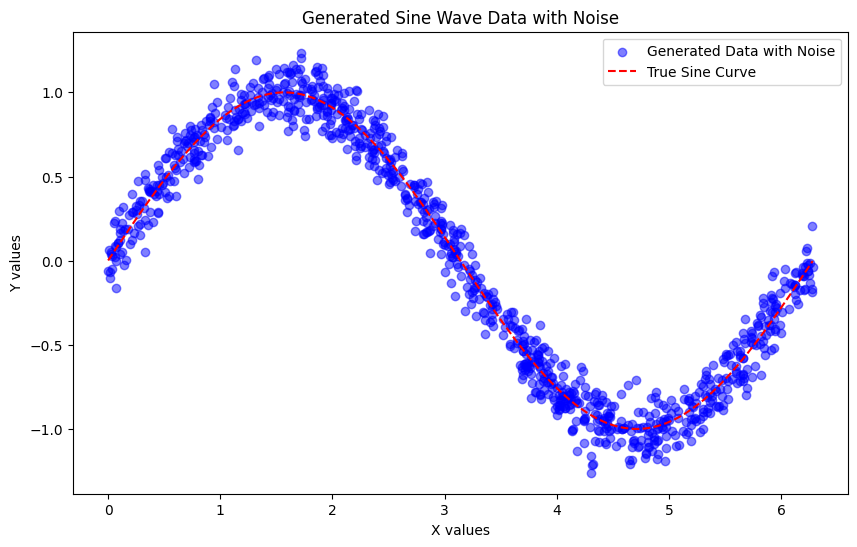

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_train, y_train,
    label='Generated Data with Noise', color='blue', alpha=0.5
)
plt.plot(
    x_train, np.sin(x_train),
    label='True Sine Curve', color='red', linestyle='--'
)

plt.legend()
plt.title('Generated Sine Wave Data with Noise')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

## Step 2:Model Define

In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, 10)
        self.activation = nn.SiLU()
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

## Step 3:Model Training

In [15]:
def train(model, optimizer, criterion, inputs, targets):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    return loss.item()

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

inputs = torch.tensor(x_train, dtype=torch.float32, requires_grad=True).view(-1, 1).to(device)
targets = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

num_epochs = 10000
for epoch in range(num_epochs):

    # Training
    loss = train(model, optimizer, criterion, inputs, targets)
    
    #optimizer.zero_grad()
    #outputs = model(inputs)
    #loss = criterion(outputs, targets)
    #loss.backward()
    #optimizer.step()

    if (epoch+1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

Epoch [500/10000], Loss: 0.1641
Epoch [1000/10000], Loss: 0.1251
Epoch [1500/10000], Loss: 0.1139
Epoch [2000/10000], Loss: 0.1005
Epoch [2500/10000], Loss: 0.0721
Epoch [3000/10000], Loss: 0.0427
Epoch [3500/10000], Loss: 0.0249
Epoch [4000/10000], Loss: 0.0158
Epoch [4500/10000], Loss: 0.0119
Epoch [5000/10000], Loss: 0.0108
Epoch [5500/10000], Loss: 0.0105
Epoch [6000/10000], Loss: 0.0105
Epoch [6500/10000], Loss: 0.0104
Epoch [7000/10000], Loss: 0.0104
Epoch [7500/10000], Loss: 0.0104
Epoch [8000/10000], Loss: 0.0104
Epoch [8500/10000], Loss: 0.0104
Epoch [9000/10000], Loss: 0.0104
Epoch [9500/10000], Loss: 0.0104
Epoch [10000/10000], Loss: 0.0104


In [11]:
def evaluate(model, x_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test.view(-1,1)).cpu().numpy()
    return y_pred

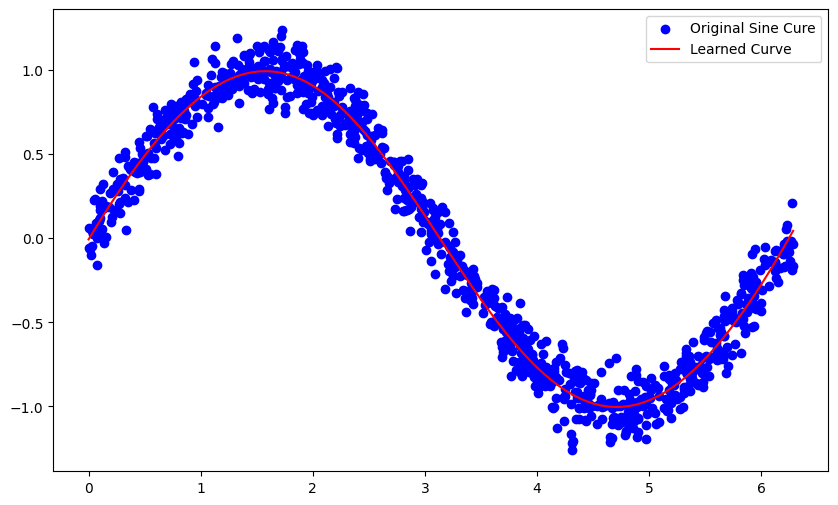

In [13]:
x_test = torch.linspace(0, 2*np.pi, 100).to(device)
y_pred = evaluate(model, x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Original Sine Cure', color='blue')
plt.plot(x_test.cpu(), y_pred, label='Learned Curve', color='red')

plt.legend()
plt.show()